# Module 9: Capstone Project

### Course: R Programming - A Comprehensive Guide

**Author:** Kajola Gbenga
**Role:** Data Scientist & AI Engineer

---


## Learning Objectives

By the end of this notebook, you will be able to:

- Plan and execute an end-to-end statistical data analysis project
- Collect and prepare a real-world data set for analysis
- Apply statistical analysis and correctly interpret the results
- Produce clear, professional data visualizations and a written report
- Present findings in a structured, audience appropriate way
- Understand how capstone projects are typically assessed

## 1. End-to-End Statistical Data Analysis Project

The capstone project brings together every module covered in this course. You will take a data set from raw form all the way to a polished report, applying the full R toolkit: data manipulation, EDA, probability and inference, regression, and reproducible reporting.

**Suggested project structure:**
1. Problem definition
2. Data collection and preparation
3. Exploratory data analysis
4. Statistical analysis and modelling
5. Visualization and reporting
6. Presentation of findings


## 2. Data Collection and Preparation

Start by clearly defining your research question, then gather and clean your data set. The template below (using `mtcars` as a stand-in) shows the pattern you should follow with your own chosen data set.

In [1]:
library(dplyr)

# ---- Step 1: Import your data ----
# df <- read.csv("your_dataset.csv")
data(mtcars)
df <- mtcars
df$car_model <- rownames(df)
rownames(df) <- NULL

# ---- Step 2: Inspect the data ----
str(df)
summary(df)
colSums(is.na(df))

# ---- Step 3: Clean and prepare ----
df_clean <- df %>%
  mutate(cyl = factor(cyl), am = factor(am, labels = c("Automatic", "Manual"))) %>%
  filter(!is.na(mpg))

head(df_clean)


Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




'data.frame':	32 obs. of  12 variables:
 $ mpg      : num  21 21 22.8 21.4 18.7 18.1 14.3 24.4 22.8 19.2 ...
 $ cyl      : num  6 6 4 6 8 6 8 4 4 6 ...
 $ disp     : num  160 160 108 258 360 ...
 $ hp       : num  110 110 93 110 175 105 245 62 95 123 ...
 $ drat     : num  3.9 3.9 3.85 3.08 3.15 2.76 3.21 3.69 3.92 3.92 ...
 $ wt       : num  2.62 2.88 2.32 3.21 3.44 ...
 $ qsec     : num  16.5 17 18.6 19.4 17 ...
 $ vs       : num  0 0 1 1 0 1 0 1 1 1 ...
 $ am       : num  1 1 1 0 0 0 0 0 0 0 ...
 $ gear     : num  4 4 4 3 3 3 3 4 4 4 ...
 $ carb     : num  4 4 1 1 2 1 4 2 2 4 ...
 $ car_model: chr  "Mazda RX4" "Mazda RX4 Wag" "Datsun 710" "Hornet 4 Drive" ...


      mpg             cyl             disp             hp       
 Min.   :10.40   Min.   :4.000   Min.   : 71.1   Min.   : 52.0  
 1st Qu.:15.43   1st Qu.:4.000   1st Qu.:120.8   1st Qu.: 96.5  
 Median :19.20   Median :6.000   Median :196.3   Median :123.0  
 Mean   :20.09   Mean   :6.188   Mean   :230.7   Mean   :146.7  
 3rd Qu.:22.80   3rd Qu.:8.000   3rd Qu.:326.0   3rd Qu.:180.0  
 Max.   :33.90   Max.   :8.000   Max.   :472.0   Max.   :335.0  
      drat             wt             qsec             vs        
 Min.   :2.760   Min.   :1.513   Min.   :14.50   Min.   :0.0000  
 1st Qu.:3.080   1st Qu.:2.581   1st Qu.:16.89   1st Qu.:0.0000  
 Median :3.695   Median :3.325   Median :17.71   Median :0.0000  
 Mean   :3.597   Mean   :3.217   Mean   :17.85   Mean   :0.4375  
 3rd Qu.:3.920   3rd Qu.:3.610   3rd Qu.:18.90   3rd Qu.:1.0000  
 Max.   :4.930   Max.   :5.424   Max.   :22.90   Max.   :1.0000  
       am              gear            carb        car_model        
 Min.   :0.000

mpg       cyl      disp        hp      drat        wt      qsec        vs 
        0         0         0         0         0         0         0         0 
       am      gear      carb car_model 
        0         0         0         0

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,car_model
,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<chr>
1,21.0,6,160,110,3.90,2.620,16.46,0,Manual,4,4,Mazda RX4
2,21.0,6,160,110,3.90,2.875,17.02,0,Manual,4,4,Mazda RX4 Wag
3,22.8,4,108,93,3.85,2.320,18.61,1,Manual,4,1,Datsun 710
4,21.4,6,258,110,3.08,3.215,19.44,1,Automatic,3,1,Hornet 4 Drive
5,18.7,8,360,175,3.15,3.440,17.02,0,Automatic,3,2,Hornet Sportabout
6,18.1,6,225,105,2.76,3.460,20.22,1,Automatic,3,1,Valiant


## 3. Statistical Analysis and Interpretation

Apply the statistical techniques relevant to your research question. The example below runs a full mini analysis: descriptive statistics, a hypothesis test, and a regression model, all on the prepared data set.

In [2]:
# ---- Descriptive statistics ----
df_clean %>%
  group_by(am) %>%
  summarise(mean_mpg = mean(mpg), sd_mpg = sd(mpg), n = n())

# ---- Hypothesis test: does transmission type affect fuel efficiency? ----
t_test_result <- t.test(mpg ~ am, data = df_clean)
t_test_result

# ---- Regression model: predicting mpg from weight and horsepower ----
model <- lm(mpg ~ wt + hp + am, data = df_clean)
summary(model)


am,mean_mpg,sd_mpg,n
<fct>,<dbl>,<dbl>,<int>
Automatic,17.14737,3.833966,19
Manual,24.39231,6.166504,13



	Welch Two Sample t-test

data:  mpg by am
t = -3.7671, df = 18.332, p-value = 0.001374
alternative hypothesis: true difference in means between group Automatic and group Manual is not equal to 0
95 percent confidence interval:
 -11.280194  -3.209684
sample estimates:
mean in group Automatic    mean in group Manual 
               17.14737                24.39231 



Call:
lm(formula = mpg ~ wt + hp + am, data = df_clean)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.4221 -1.7924 -0.3788  1.2249  5.5317 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 34.002875   2.642659  12.867 2.82e-13 ***
wt          -2.878575   0.904971  -3.181 0.003574 ** 
hp          -0.037479   0.009605  -3.902 0.000546 ***
amManual     2.083710   1.376420   1.514 0.141268    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.538 on 28 degrees of freedom
Multiple R-squared:  0.8399,	Adjusted R-squared:  0.8227 
F-statistic: 48.96 on 3 and 28 DF,  p-value: 2.908e-11


## 4. Data Visualization and Reporting

Every capstone project should include a small set of clear, well labeled visualizations that support your conclusions - not simply decorate the report.

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
`geom_smooth()` using formula = 'y ~ x'


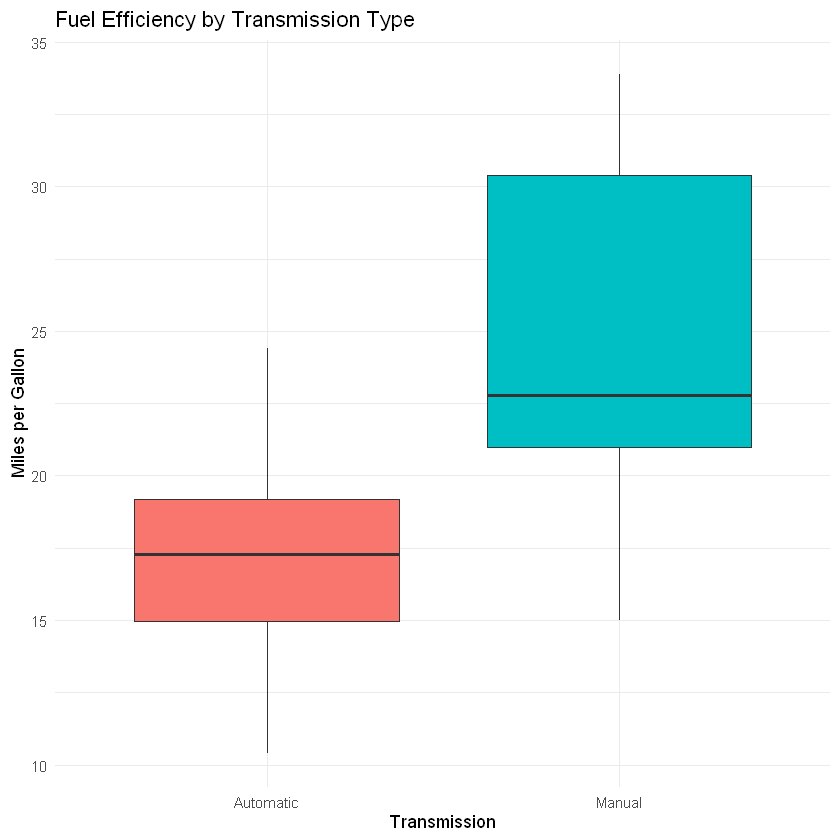

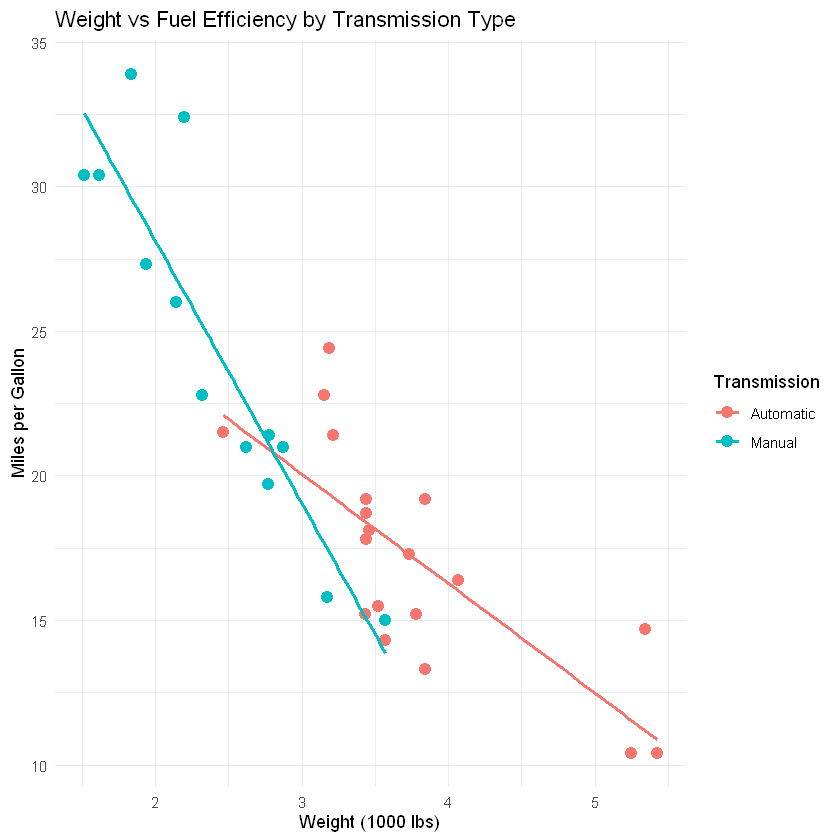

: 

In [ ]:
library(ggplot2)

# Comparison of fuel efficiency by transmission type
ggplot(df_clean, aes(x = am, y = mpg, fill = am)) +
  geom_boxplot() +
  labs(title = "Fuel Efficiency by Transmission Type",
       x = "Transmission", y = "Miles per Gallon") +
  theme_minimal() +
  theme(legend.position = "none")

# Relationship between weight and mpg, colored by transmission
ggplot(df_clean, aes(x = wt, y = mpg, color = am)) +
  geom_point(size = 3) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(title = "Weight vs Fuel Efficiency by Transmission Type",
       x = "Weight (1000 lbs)", y = "Miles per Gallon", color = "Transmission") +
  theme_minimal()

# Save the report ready plots
# ggsave("mpg_by_transmission.png", width = 7, height = 5)


## 5. Presentation of Findings

When presenting your capstone project, structure your delivery around a clear narrative:
1. **Context** - why does this analysis matter?
2. **Method** - what data and techniques did you use?
3. **Findings** - what did you discover, supported by visuals?
4. **Limitations** - what are the constraints of your analysis?
5. **Recommendations** - what should the audience do with this information?

Tips for a strong presentation:
- Lead with the key insight, not the methodology
- Use one clear chart per slide, not dense tables
- Keep statistical jargon to a minimum for non-technical audiences
- Practice explaining your findings in plain language


## 6. Final Project Assessment and Feedback

Capstone projects are typically assessed against criteria such as:

| Criterion | What is evaluated |
|-----------|--------------------|
| Problem definition | Is the research question clear and relevant? |
| Data preparation | Is the data cleaned and transformed appropriately? |
| Statistical rigor | Are the correct methods applied and assumptions checked? |
| Visualization quality | Are charts clear, accurate, and well labeled? |
| Reproducibility | Can the analysis be re-run and reproduced? |
| Communication | Are findings explained clearly for the intended audience? |

Use this table as a self-review checklist before submitting your final project.

## Capstone Project Template Checklist

- [ ] Research question clearly defined
- [ ] Data imported and inspected
- [ ] Missing values and outliers handled
- [ ] Exploratory data analysis completed with visuals
- [ ] Appropriate statistical test(s) or model(s) applied
- [ ] Model assumptions checked
- [ ] Results interpreted in plain language
- [ ] R Markdown report generated
- [ ] Presentation prepared and rehearsed


---

## Module Summary

This notebook has walked through the core concepts, R code demonstrations, and practice exercises for this module. Review each section, run every code cell yourself, and attempt the practice exercises before moving to the next module.

**Kajola Gbenga**
Data Scientist & AI Engineer